### Loading the dataset
This is the newly feature engineered dataset from `feature_engineering.ipynb`

In [1]:
import pandas as pd
import numpy as np

# loading the dataset into dataframe
df = pd.read_csv('../data/features.csv')

df.head()

,timestamp,server_id,cpu_percent,memory_percent,disk_io,is_anomaly,anomaly_type,cpu_percent_roll_mean_5,cpu_percent_roll_standard_deviation_5,cpu_percent_roll_mean_10,...,hour,day_of_week,cpu_percent_rate_of_change,memory_percent_rate_of_change,disk_io_rate_of_change,server_type_batch_worker,server_type_cache,server_type_database,server_type_load_balancer,server_type_web
0,2025-01-01 00:10:00,web_1,23.238443,36.885905,57.091144,0,normal,20.896125,2.244988,20.896125,...,0,2,3.929764,11.191153,13.110116,0,0,0,0,1
1,2025-01-01 00:15:00,web_1,27.615149,35.100183,51.622232,0,normal,21.676897,2.085378,21.676897,...,0,2,4.376707,-1.785722,-5.468912,0,0,0,0,1
2,2025-01-01 00:20:00,web_1,18.829233,28.184342,33.647097,0,normal,23.161460,3.422705,23.161460,...,0,2,-8.785916,-6.915841,-17.975135,0,0,0,0,1
3,2025-01-01 00:25:00,web_1,18.829315,34.272010,40.813835,0,normal,22.295015,3.541161,22.295015,...,0,2,0.000082,6.087668,7.166738,0,0,0,0,1
4,2025-01-01 00:30:00,web_1,27.896064,31.706079,48.501220,0,normal,21.564164,3.855648,21.717398,...,0,2,9.066749,-2.565931,7.687384,0,0,0,0,1


### Dropping columns 
Dropping the following:
- `timestamp`: raw datetime, not usuable
- `server_id`: just use the lable or identifier

### Training the model using Isolation forest: full 39 feature set

In [2]:
# Splitting the dataframe into testing and training sets
train_df = df[df['timestamp'] < '2025-01-15 00:00:00']
test_df = df[df['timestamp'] >= '2025-01-15 00:00:00']

print(len(train_df))
print(len(test_df))

print(train_df['is_anomaly'].value_counts())
print(test_df['is_anomaly'].value_counts())

60464
30240
is_anomaly
0    60396
1       68
Name: count, dtype: int64
is_anomaly
0    30139
1      101
Name: count, dtype: int64


In [3]:
print(df[['timestamp', 'server_id',
          'cpu_percent',
          'cpu_percent_roll_mean_5',
          'cpu_percent_zscore_5']].head(10))

             timestamp server_id  cpu_percent  cpu_percent_roll_mean_5  \
0  2025-01-01 00:10:00     web_1    23.238443                20.896125   
1  2025-01-01 00:15:00     web_1    27.615149                21.676897   
2  2025-01-01 00:20:00     web_1    18.829233                23.161460   
3  2025-01-01 00:25:00     web_1    18.829315                22.295015   
4  2025-01-01 00:30:00     web_1    27.896064                21.564164   
5  2025-01-01 00:35:00     web_1    23.837174                23.281641   
6  2025-01-01 00:40:00     web_1    17.652628                23.401387   
7  2025-01-01 00:45:00     web_1    22.712800                21.408883   
8  2025-01-01 00:50:00     web_1    17.682912                22.185596   
9  2025-01-01 00:55:00     web_1    17.671351                21.956316   

   cpu_percent_zscore_5  
0              1.043354  
1              2.847566  
2             -1.265732  
3             -0.978690  
4              1.642240  
5              0.124438  
6  

In [4]:
y = df['is_anomaly']
# `is_anomaly`: this is the ground truth label, and shoulnd't be used during training
X = df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X.shape)
print(X.columns)
print(y.value_counts())


(90704, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore_

In [5]:
# calculate the contamination rate 
contamination_rate = y.sum() / len(y)
print(contamination_rate)

0.0018632033868407126


In [6]:
# fit the model with the dataframe
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination=contamination_rate, random_state=42).fit(X)

In [7]:
predictions = clf.predict(X)
print(pd.Series(predictions).value_counts())

 1    90535
-1      169
Name: count, dtype: int64


### Classification report 
`Precision` - How many of the true positves flagged by the model is accurate 
$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
`Recall` - How many actually true positives did the model catch 
$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
`F1-score1` - This is the harmonic mean of the recall and precison
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The precison, recall and f1-score (for this first round of training the model) for class `1` is extremley low, meaning the model is not catching anything almost correctly.

In [8]:
# check the models predictions
from sklearn.metrics import classification_report

# if predictions == -1, this would output True
# .astype will convert True to 1
predictions_binary = (predictions == -1).astype(int) # converts -1 to 1

# classification report on the predicitons
classification_report_full_set = classification_report(y, predictions_binary)
print(classification_report_full_set)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90535
           1       0.02      0.02      0.02       169

    accuracy                           1.00     90704
   macro avg       0.51      0.51      0.51     90704
weighted avg       1.00      1.00      1.00     90704



### Diagnosing the failure
Using `decision_function` to check whether the true anomalies show up as clearly negative
scores, or whether they blend into the normal range.

What was found:
- There is a measurable difference — anomaly scores are lower on average (`0.147` vs `0.215`)
- The two distributions overlap a lot, meaning individual rows are often not distinguishable
  from one another

This suggests the model is learning something real, but the signal is weak.

In [9]:
df['anomaly_score'] = clf.decision_function(X)
print(df[df['is_anomaly'] == 1]['anomaly_score'].describe())
print(df[df['is_anomaly'] == 0]['anomaly_score'].describe())

count    169.000000
mean       0.127786
std        0.056458
min       -0.019954
25%        0.088203
50%        0.122029
75%        0.181088
max        0.245315
Name: anomaly_score, dtype: float64
count    90535.000000
mean         0.202874
std          0.050686
min         -0.029277
25%          0.186174
50%          0.220070
75%          0.237118
max          0.271242
Name: anomaly_score, dtype: float64


#### Investigating how extreme the anomalies are
Looking into `web_1` to compare the `anomaly_score`'s for a non-anomaly and anomaly, to see if there is a spike

What was found:
- The anomaly_scores didn't reflect the anomalies clearly, showing no spike or dip
- The anomalies blended into the rest of the data

               timestamp  is_anomaly  anomaly_score
2698 2025-01-10 09:00:00           0       0.109059
2699 2025-01-10 09:05:00           0       0.117878
2700 2025-01-10 09:10:00           0       0.113895
2701 2025-01-10 09:15:00           0       0.119222
2702 2025-01-10 09:20:00           0       0.132886
2703 2025-01-10 09:25:00           0       0.140310
2704 2025-01-10 09:30:00           0       0.140428
2705 2025-01-10 09:35:00           0       0.125187
2706 2025-01-10 09:40:00           0       0.138391
2707 2025-01-10 09:45:00           0       0.146358
2708 2025-01-10 09:50:00           0       0.152843
2709 2025-01-10 09:55:00           0       0.139862
2710 2025-01-10 10:00:00           1       0.113012
2711 2025-01-10 10:05:00           1       0.099837
2712 2025-01-10 10:10:00           1       0.108588
2713 2025-01-10 10:15:00           1       0.106961
2714 2025-01-10 10:20:00           1       0.119004
2715 2025-01-10 10:25:00           1       0.107941
2716 2025-01

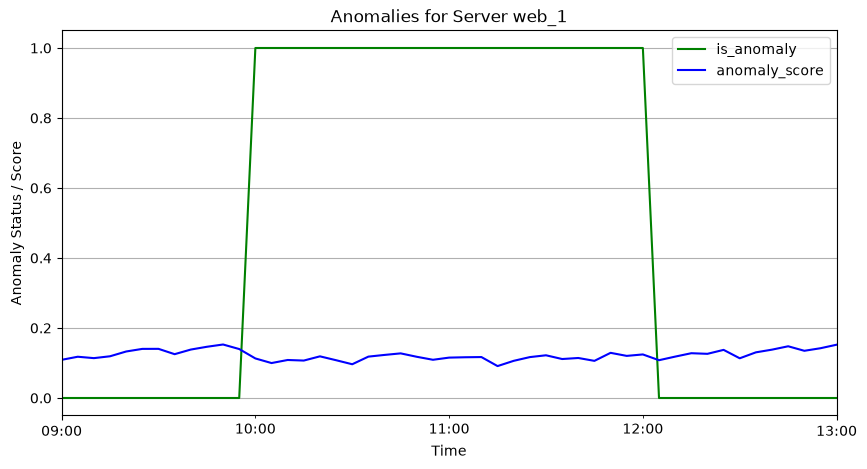

In [10]:
import matplotlib.pyplot as plt\

df['timestamp'] = pd.to_datetime(df['timestamp'])

start_time = '2025-01-10 09:00:00'
end_time = '2025-01-10 13:00:00'

condition = (df['server_id'] == 'web_1') & (df['timestamp'].between(start_time, end_time))

plot_data = df[condition][['timestamp','is_anomaly', 'anomaly_score']]
print(plot_data)

plot_data = plot_data.set_index('timestamp') # make timestamp the index of the dataframe

plot_data.plot(figsize=(10, 5), kind='line',color=['green','blue'], title='Anomalies for Server web_1')
plt.ylabel('Anomaly Status / Score')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [11]:
# check the cpu_percent anomalies for web_1 are present
# confirm if that some data is missing
df[(df['server_id'] == 'web_1') & (df['is_anomaly'] == 1)]['cpu_percent'].describe()

count     25.000000
mean      94.096024
std        4.667200
min       83.458590
25%       92.199874
50%       95.118247
75%       97.395977
max      100.000000
Name: cpu_percent, dtype: float64

### Hypothesis 1: The feature set is too large. 
As isolation forest builds trees based on randomly selected features, with so many features and where only a handful of them hold a strong signal of an anomaly, there is a chance that the model is splitting on irrelevant features which don't relate to the particular anomaly.

**Next experiment**: Train the model using a smaller feature set, using more targeted features.

In [12]:
X_small = df[['cpu_percent','cpu_percent_zscore_5','cpu_percent_zscore_10','cpu_percent_zscore_30','server_type_batch_worker','server_type_cache','server_type_database','server_type_load_balancer','server_type_web']]
 
# cpu percent only, contamination rate
cpu_percent_anomalies = df.loc[(df['anomaly_type'] == 'cpu_anomaly') & (df['is_anomaly'] == 1)]
print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_smaller_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_smaller_set}')

# train the model usint the new feature set
clf_smaller_set = IsolationForest(contamination=contamination_rate_smaller_set, random_state=42).fit(X_small)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.0012017110601517023


In [13]:
# Predict using the trained model
predictions_small_set = clf_smaller_set.predict(X_small)
print(pd.Series(predictions_small_set).value_counts())

predictions_binary_small_set = (predictions_small_set == -1).astype(int)

y_cpu_only = (df['anomaly_type'] == 'cpu_anomaly').astype(int)
# classification report on the predicitons
classification_report_small_set = classification_report(y_cpu_only, predictions_binary_small_set)
print(classification_report_small_set)

 1    90596
-1      108
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90595
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90704
   macro avg       0.50      0.50      0.50     90704
weighted avg       1.00      1.00      1.00     90704



From the above experiment, it is clear even modelling on a smaller featrue set doesn't seem to imporove the model. However it has highlighted that the raw data values need to be looked into a little more.

The raw `cpu_percent` values need to be considered, for `batch_worker` server type the cpu_percent is 0 for majority of the day. This means a huge chunk of the whole dataset is sitting around 0. Isolation forest is based on random splits of randomly chosen features, the raw values are incomparable compared to other values within the dataset. Specifcially for `cpu_percent`, `web_1` server raw values can't be comapred to the `batch_worker`'s (constant 0) raw values 

And below we see that the `precision`,`recall` and `f1-score` are still 0.00. This shows that the number of features doesn't affect the models perfomance detecting anomalies.

In [14]:
X_zscore = df[['cpu_percent_zscore_5', 'cpu_percent_zscore_10', 'cpu_percent_zscore_30']]

print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_zscore_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_zscore_set}')

# train the model usint the new feature set
clf_zscore = IsolationForest(contamination=contamination_rate_zscore_set, random_state=42).fit(X_zscore)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.0012017110601517023


In [15]:
# Predict using the trained model
predictions_zscore_set = clf_zscore.predict(X_zscore)
print(pd.Series(predictions_zscore_set).value_counts())

predictions_binary_zscore_set = (predictions_zscore_set == -1).astype(int)

# classification report on the predicitons
classification_report_zscore_set = classification_report(y_cpu_only, predictions_binary_zscore_set)
print(classification_report_zscore_set)

 1    90596
-1      108
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90595
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90704
   macro avg       0.50      0.50      0.50     90704
weighted avg       1.00      1.00      1.00     90704



In [16]:
anomalies = df[df['is_anomaly'] == 1]
pd.set_option('display.max_rows', None)
print(
    anomalies[
        ['server_id', 'anomaly_type', 'anomaly_score']
    ].sort_values('anomaly_score')
)
pd.reset_option('display.max_rows')

             server_id     anomaly_type  anomaly_score
87856   batch_worker_3  disk_io_anomaly      -0.019954
87857   batch_worker_3  disk_io_anomaly      -0.014826
87858   batch_worker_3  disk_io_anomaly      -0.011613
87860   batch_worker_3  disk_io_anomaly      -0.009567
87859   batch_worker_3  disk_io_anomaly       0.006221
83820   batch_worker_2   memory_anomaly       0.027219
29785       database_2      cpu_anomaly       0.039524
83818   batch_worker_2   memory_anomaly       0.041782
83819   batch_worker_2   memory_anomaly       0.041945
29791       database_2      cpu_anomaly       0.044884
29786       database_2      cpu_anomaly       0.047812
29798       database_2      cpu_anomaly       0.055987
22341       database_1  disk_io_anomaly       0.058151
76352   batch_worker_1      cpu_anomaly       0.058528
76365   batch_worker_1      cpu_anomaly       0.060180
76351   batch_worker_1      cpu_anomaly       0.061296
29789       database_2      cpu_anomaly       0.062310
76359   ba

### Hypothesis 2: Data heterogeneity across server types

With 5 structurally different server types (15 servers total) sharing a single Isolation
Forest, the model's notion of "normal" is being shaped by all five distributions at once —
in particular, `batch_worker`'s mostly-zero, briefly-spiking pattern appears to dominate the
overall score scale, based on the sorted anomaly-score investigation above. Including
`server_type` as a one-hot feature was an attempt to let the model condition on this
difference, but the experiments above (full feature set, reduced feature set, Z-score-only
feature set) all produced near-identical, near-zero precision/recall for the anomaly class —
suggesting the model isn't reliably learning to separate "normal" per server type from a
single shared training pass.

**Next experiment:** train 5 separate Isolation Forest models, one per `server_type`, each
learning "normal" from only its own server type's data. Evaluate each model against the
anomalies belonging to its own server type, rather than scoring all 15 servers with one
shared model and threshold.

### Server type: Web

In [17]:
# filter down df by server_type_web
filtered_df_web = df[df['server_type_web'] == 1]

y_web = filtered_df_web['is_anomaly']
X_web = filtered_df_web.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

# calculate the contamination rate 
contamination_rate_web = y_web.sum()/len(y_web)
print(f'Contamination rate for web server:{contamination_rate_web}')

Contamination rate for web server:0.003858875413450937


In [18]:
# train isolation forest model on web server type
clf_web = IsolationForest(contamination=contamination_rate_web, random_state=42).fit(X_web)

In [19]:
predictions_web = clf_web.predict(X_web)
print(pd.Series(predictions_web).value_counts())

predictions_binary_web = (predictions_web == -1).astype(int)
# conatmination rate
classification_report_web = classification_report(y_web, predictions_binary_web)
print(classification_report_web)

 1    18070
-1       70
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18070
           1       0.00      0.00      0.00        70

    accuracy                           0.99     18140
   macro avg       0.50      0.50      0.50     18140
weighted avg       0.99      0.99      0.99     18140

